In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
import os
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 150)

<b>1. Load Main Application Data</b>

In [33]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
print(f"\nCommon features: {len(set(df.columns))}")

Shape: (7043, 21)

Common features: 21


In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset contains customer-level information from a telecommunications company. Each row represents a single customer and includes demographic attributes, subscribed services, billing information, and the target variable indicating whether the customer churned.
Initial inspection shows that the dataset consists of 7043 observations and multiple categorical and numerical features.
Understanding the structure of the dataset is important before performing further preprocessing and modeling steps.

<b>2. Target Variable Analysis</b>

Target Distribution:
0 (No Churn): 5,174 (73.46%)
1 (Churn): 1,869 (26.54%)


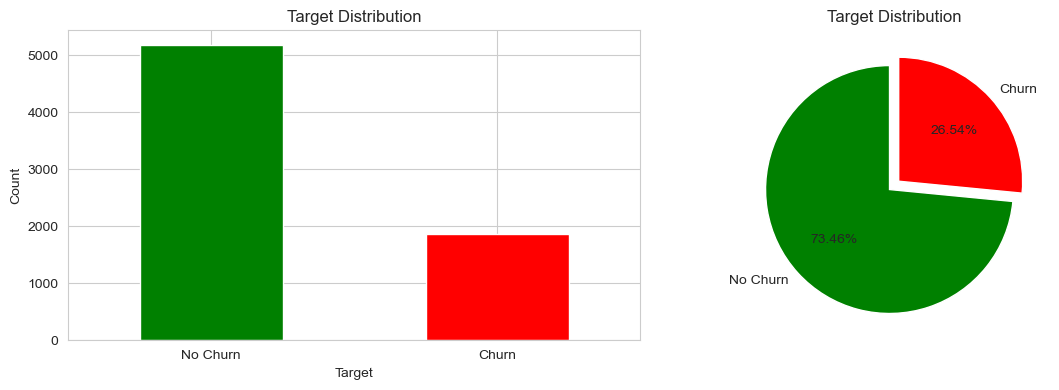

In [35]:
target = "Churn"
target_counts=df[target].value_counts()
target_pct=df[target].value_counts(normalize=True) * 100

print("Target Distribution:")
print(f"0 (No Churn): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"1 (Churn): {target_counts[1]:,} ({target_pct[1]:.2f}%)")

fig, ax=plt.subplots(1,2, figsize=(12,4))

df[target].value_counts().plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Target Distribution')
ax[0].set_xlabel('Target')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

labels=['No Churn', 'Churn']
colors= ['green', 'red']
explode = (0.05, 0.05)
ax[1].pie(df[target].value_counts().values, labels=labels, colors=colors,
         autopct='%1.2f%%', startangle=90, explode=explode,textprops={'fontsize':10})
ax[1].set_title('Target Distribution')

plt.tight_layout()
plt.show()


The distribution shows a clear class imbalance:
- Approximately **73.46% of customers did not churn**
- Approximately **26.54% of customers churned**

This imbalance is typical in churn prediction problems because the majority of customers tend to remain with the company.

From a business perspective, correctly identifying customers who are likely to churn is critical because losing customers directly affects company revenue. Therefore, during model evaluation, special attention should be given to metrics that reflect the model's ability to correctly detect churners.

<b>3. Data Types Analysis</b>

In [36]:
print("Data Types:")
print(df.dtypes.value_counts())

Data Types:
object     18
int64       2
float64     1
Name: count, dtype: int64


In [37]:
def analyze_columns(df):
    analysis=pd.DataFrame({
        'dtype': df.dtypes,
        'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
        'unique_count':df.nunique(),
        'unique_pct':(df.nunique() / len(df) * 100).round(2)
    })
    analysis['category']='numeric'
    analysis.loc[analysis['dtype'] == 'object', 'category'] = 'categorical'
    analysis.loc[analysis['unique_count']==1, 'category'] = 'constant'
    
    analysis.loc[analysis['unique_count'] == len(df), 'category'] = 'unique_id'
    return analysis

col_analysis=analyze_columns(df)
print("Column Analysis:")
col_analysis
    

Column Analysis:


,dtype,null_pct,unique_count,unique_pct,category
customerID,object,0.0,7043,100.00,unique_id
gender,object,0.0,2,0.03,categorical
SeniorCitizen,int64,0.0,2,0.03,numeric
Partner,object,0.0,2,0.03,categorical
Dependents,object,0.0,2,0.03,categorical
tenure,int64,0.0,73,1.04,numeric
PhoneService,object,0.0,2,0.03,categorical
MultipleLines,object,0.0,3,0.04,categorical
InternetService,object,0.0,3,0.04,categorical
OnlineSecurity,object,0.0,3,0.04,categorical


In [38]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce'
)


In [39]:
col_analysis=analyze_columns(df)
print("Column Analysis:")
col_analysis
    

Column Analysis:


,dtype,null_pct,unique_count,unique_pct,category
customerID,object,0.00,7043,100.00,unique_id
gender,object,0.00,2,0.03,categorical
SeniorCitizen,int64,0.00,2,0.03,numeric
Partner,object,0.00,2,0.03,categorical
Dependents,object,0.00,2,0.03,categorical
tenure,int64,0.00,73,1.04,numeric
PhoneService,object,0.00,2,0.03,categorical
MultipleLines,object,0.00,3,0.04,categorical
InternetService,object,0.00,3,0.04,categorical
OnlineSecurity,object,0.00,3,0.04,categorical


Analyzing feature data types helps identify how each variable should be processed during the modeling phase.

The dataset contains both **categorical** and **numerical** variables. Categorical variables mainly represent customer attributes and service types, while numerical variables represent billing information and tenure.

Correctly identifying feature types is essential for applying appropriate preprocessing techniques such as:
- Encoding categorical variables
- Scaling numerical variables
- Handling missing values

<b>4. Missing Values</b>

In [40]:
missing_stats=pd.DataFrame({
    'data_count':len(df),
    'data_null_count':df.isnull().sum(),
    'data_missing_%':(df.isnull().sum() / len(df) * 100).round(2)
})
display(missing_stats)

,data_count,data_null_count,data_missing_%
customerID,7043,0,0.00
gender,7043,0,0.00
SeniorCitizen,7043,0,0.00
Partner,7043,0,0.00
Dependents,7043,0,0.00
tenure,7043,0,0.00
PhoneService,7043,0,0.00
MultipleLines,7043,0,0.00
InternetService,7043,0,0.00
OnlineSecurity,7043,0,0.00


In [41]:
df['TotalCharges_missing'] = df['TotalCharges'].isna().astype(int)
df['TotalCharges'] = df['TotalCharges'].fillna(0)


In [42]:
df.groupby('TotalCharges_missing')['Churn'].value_counts(normalize=True)


TotalCharges_missing  Churn
0                     No       0.734215
                      Yes      0.265785
1                     No       1.000000
Name: proportion, dtype: float64

In [43]:
df['TotalCharges_missing'].value_counts()


TotalCharges_missing
0    7032
1      11
Name: count, dtype: int64

In [44]:
df.drop(columns=['TotalCharges_missing'], inplace=True)

<b>5. Features Analysis</b>

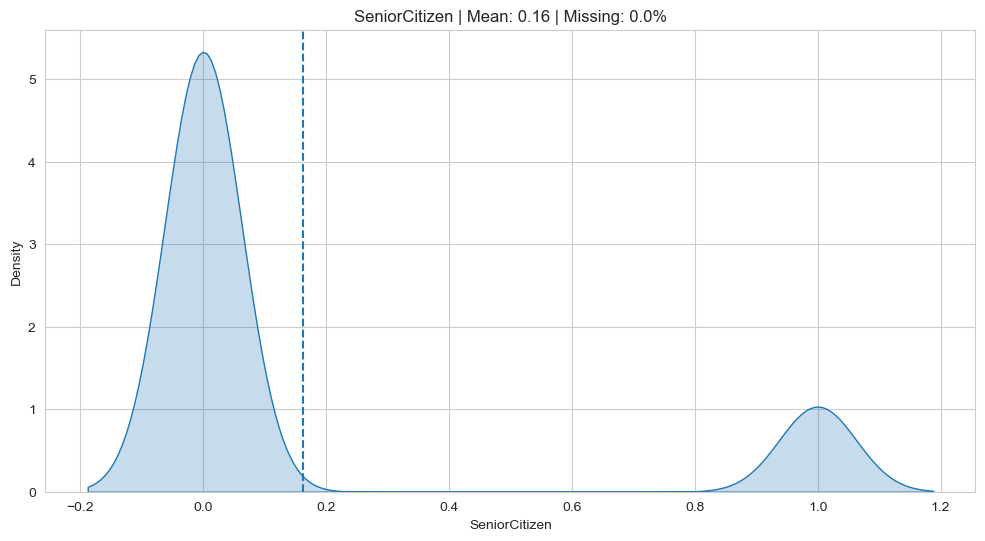

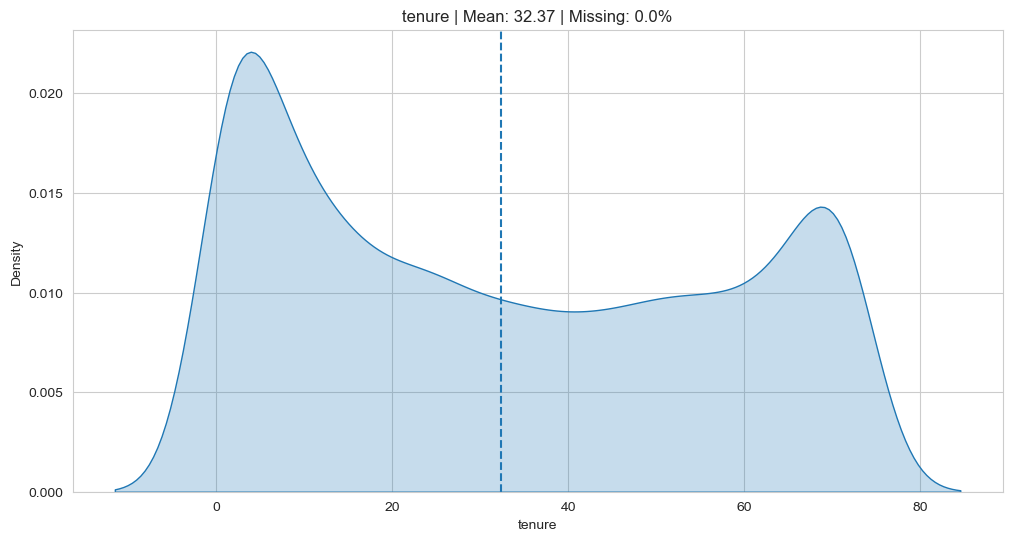

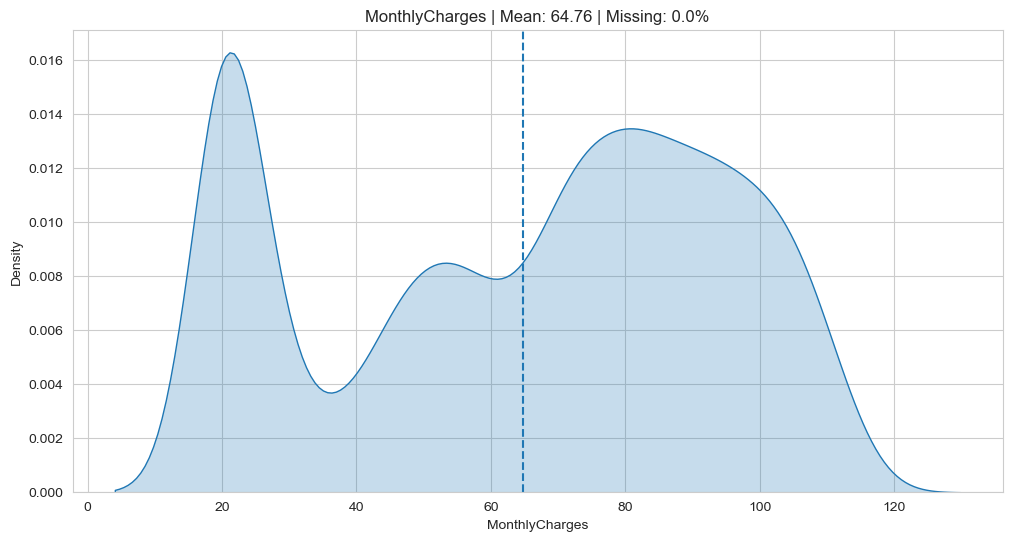

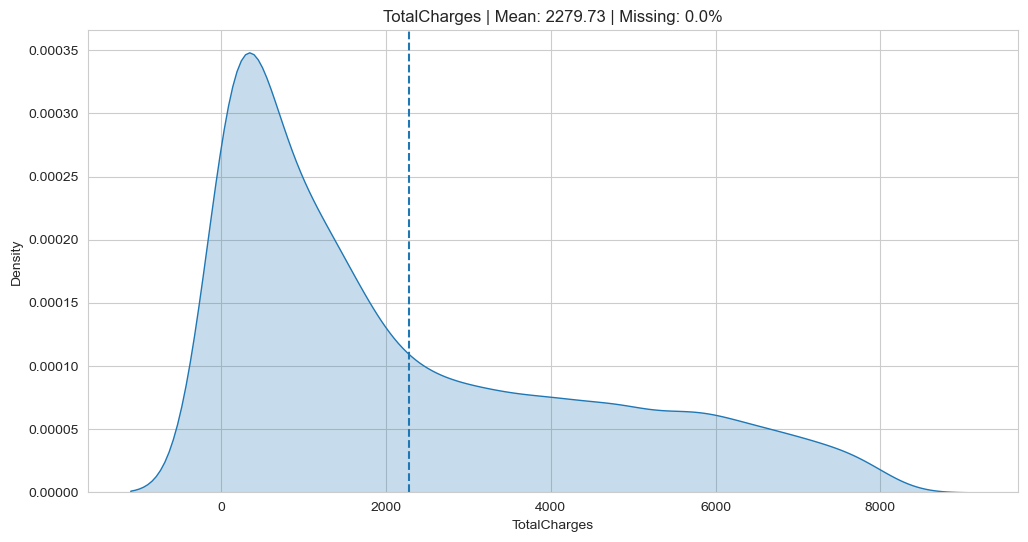

In [45]:
demographic_features=['gender', 'SeniorCitizen', 'Partner', 'Dependents']
tenure_features=['tenure']
core_services=['PhoneService','MultipleLines','InternetService']
value_added_services=['OnlineSecurity', 'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
contract_billing=['Contract','PaperlessBilling','PaymentMethod']
charges=['MonthlyCharges','TotalCharges']
selected_features=demographic_features+tenure_features+core_services+value_added_services+contract_billing+charges

data_plot=df[selected_features].copy()

for col in selected_features:
    data=data_plot[col]
    
   
    if pd.api.types.is_numeric_dtype(data):
        q01 = data.quantile(0.01)
        q99 = data.quantile(0.99)
        data_filtered=data[(data >= q01) & (data <=q99)]
        
        mean= data.mean()
        missing=data.isna().mean() * 100
        
        sns.kdeplot(data_filtered, fill=True)
        plt.axvline(mean,linestyle='--')
        
        plt.title(f'{col} | Mean: {mean:.2f} | Missing: {missing:.1f}%')
   
    
    plt.show()

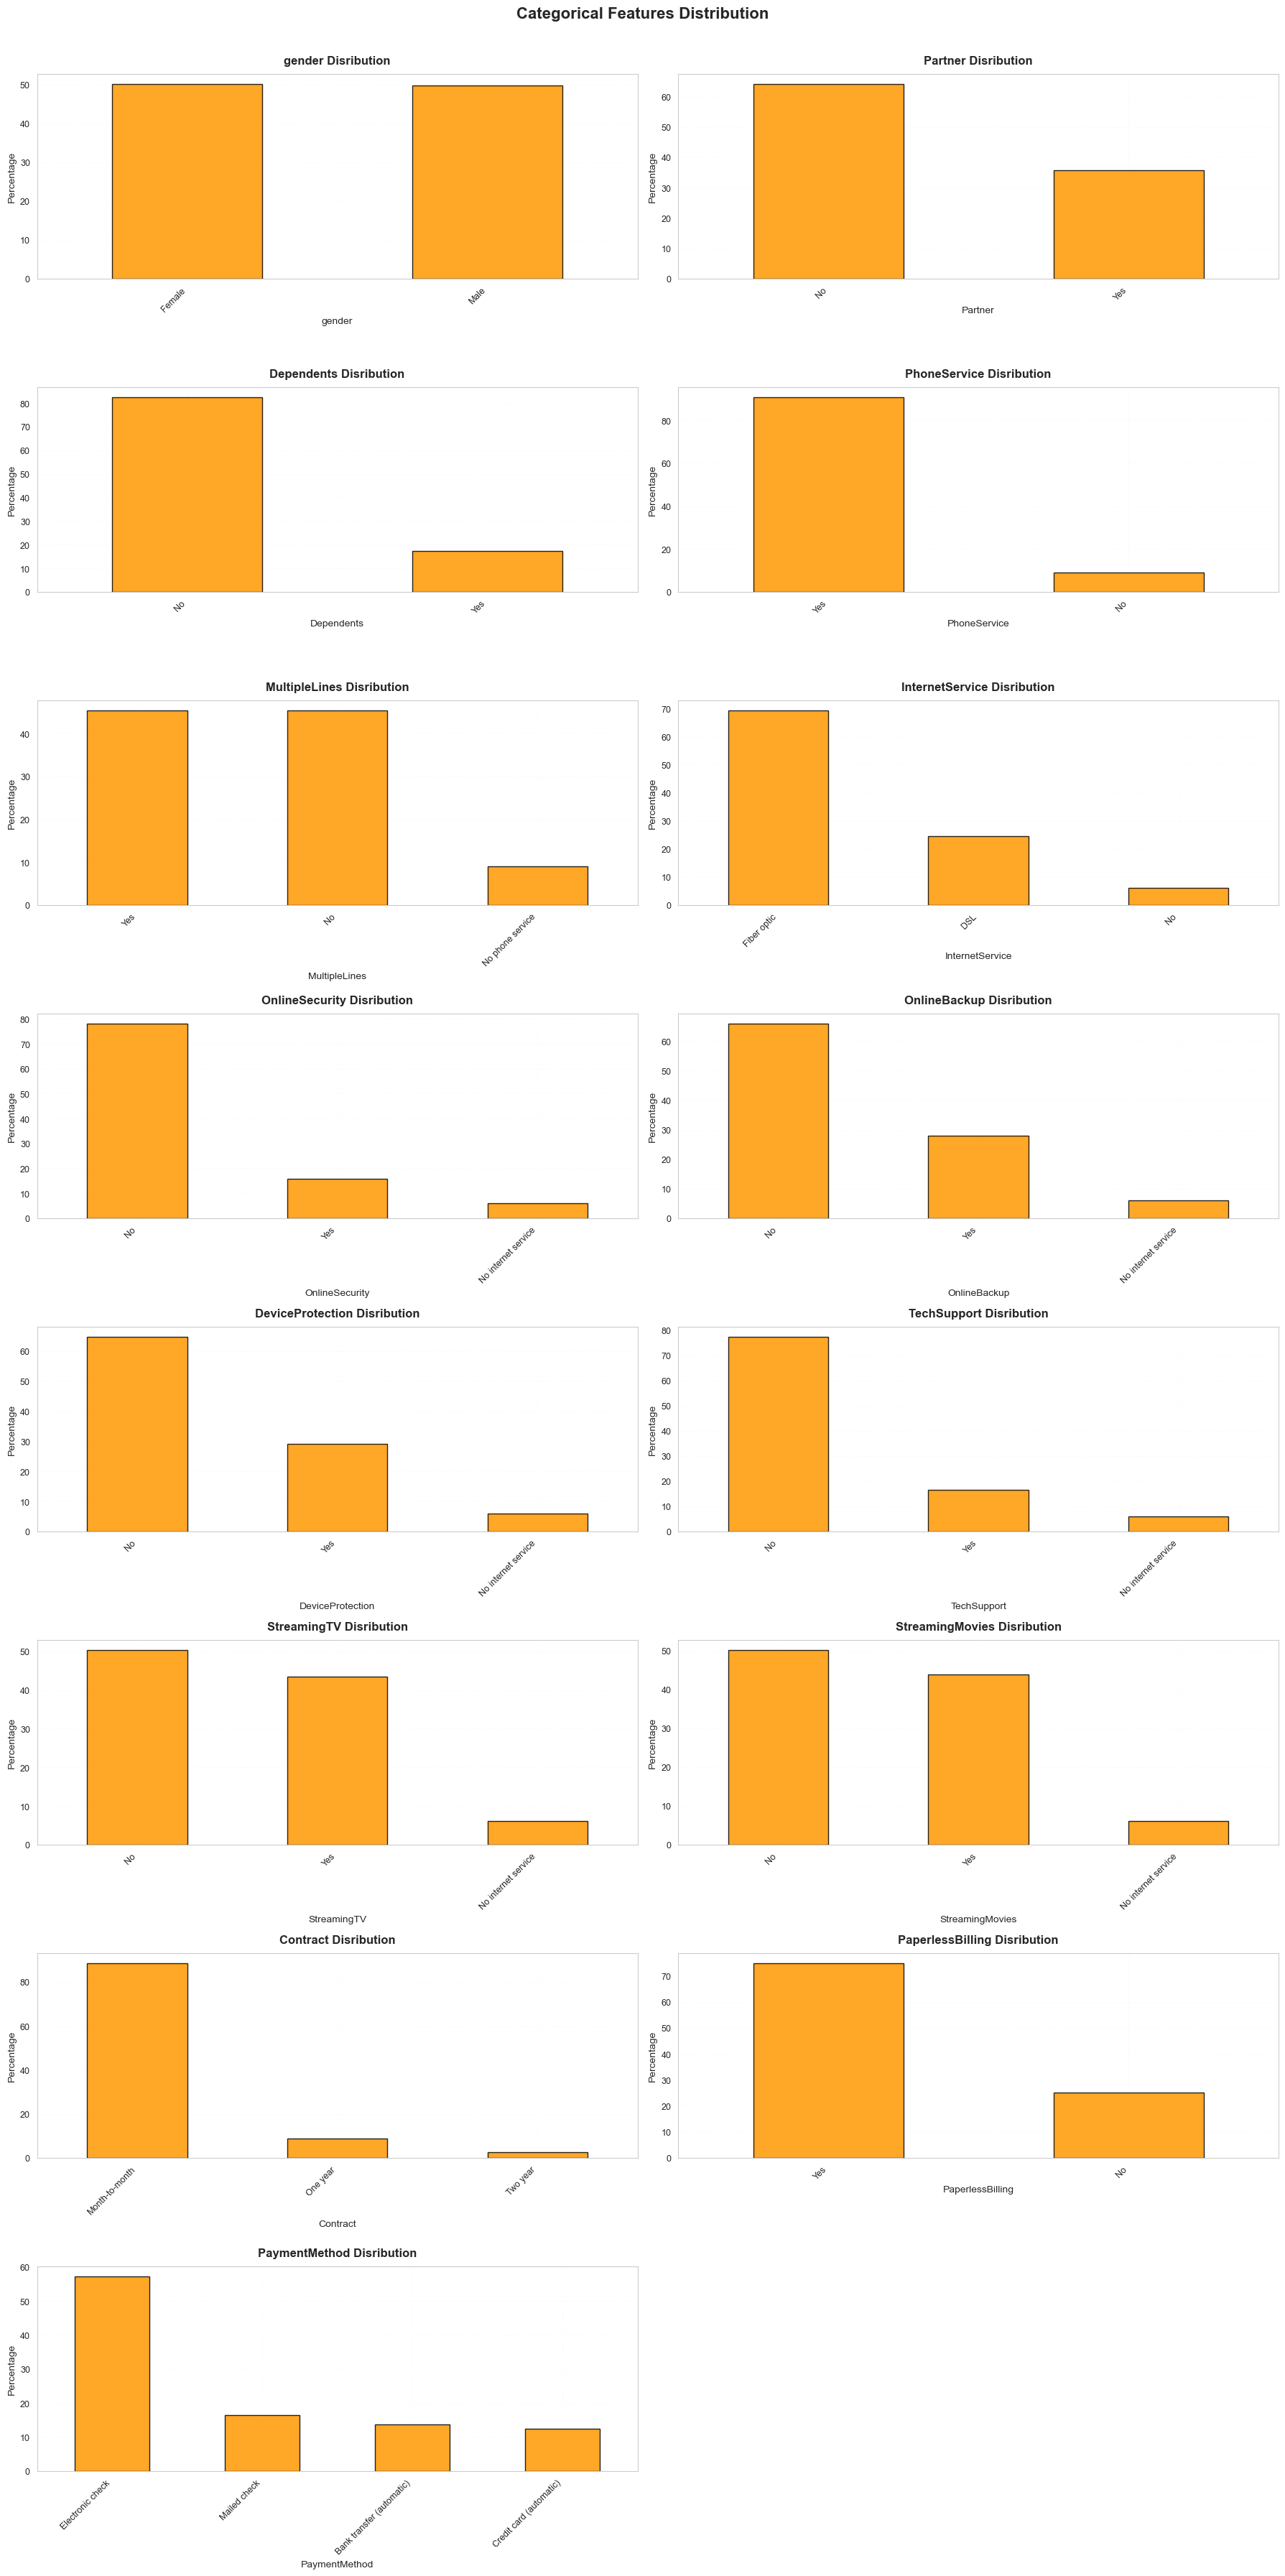

In [46]:
categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features = [
    col for col in categorical_features
    if col not in ['dataset', 'customerID','Churn']
]


df_churned=df[df[target]=='Yes']
n_cols = 2

n_rows = int(np.ceil(len(categorical_features) / n_cols))
fig, axes=plt.subplots(n_rows, n_cols, figsize=(18, n_rows *4.5))
axes= axes.ravel()

bar_color = '#FF9800'


for i, col in enumerate(categorical_features):
    if col not in df_default.columns:
        continue
    value_counts=df_churned[col].value_counts(normalize=True) * 100
    value_counts.plot(kind='bar', ax=axes[i], color=bar_color, alpha=0.85, edgecolor='black')
    axes[i].set_title(f'{col} Disribution', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')
    axes[i].grid(True, alpha=0.2, linestyle=':', linewidth=0.5)
    axes[i].tick_params(labelsize=9)
    axes[i].set_axisbelow(True)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

for j in range(len(categorical_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()
    

In [47]:
df['Churn_BIN'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [48]:
df[['Churn', 'Churn_BIN']].head()
df['Churn_BIN'].value_counts()

Churn_BIN
0    5174
1    1869
Name: count, dtype: int64

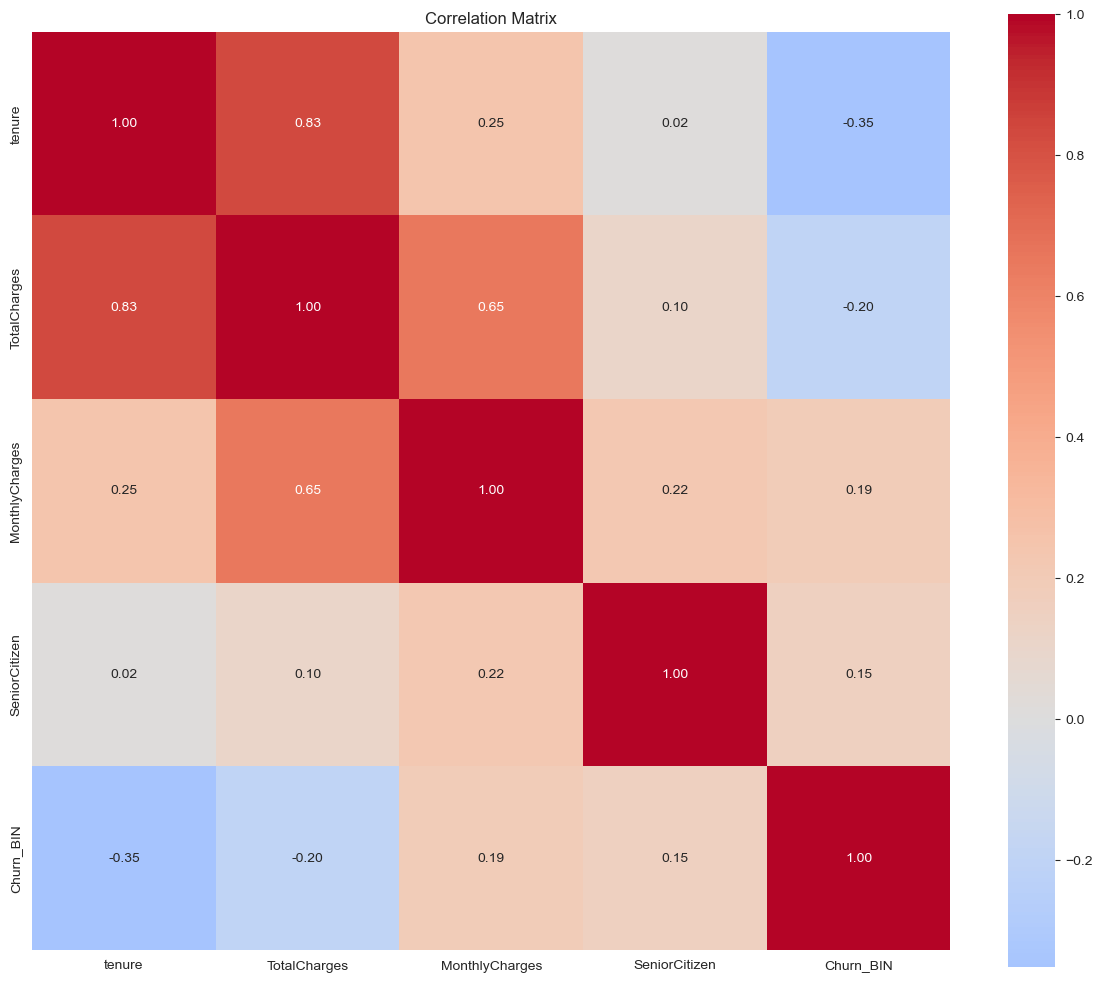

In [49]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in ['Churn_BIN']:
    if col in numeric_cols:
        numeric_cols.remove(col)

correlations = (
    df[numeric_cols + ['Churn_BIN']].corr()['Churn_BIN'].sort_values(ascending=False)
)
top_features = (correlations.abs().sort_values(ascending=False).index.tolist())
top_features.remove('Churn_BIN')

plt.figure(figsize=(12,10))
corr_matrix=df[top_features + ['Churn_BIN']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

<h1>Feature Analysis</h1>

To better understand the structure of the dataset and the characteristics of each variable, a detailed feature analysis was conducted. The goal of this analysis is to identify the types of features present in the dataset and determine how they should be handled during preprocessing and modeling stages.

<b>Categorical Feature Analysis</b>

Categorical features were examined to understand how customer characteristics and service subscriptions relate to churn behavior.Visualizing the distribution of these features provides insight into how different categories are represented in the dataset and whether certain groups show higher churn tendencies.

For example, customers with short-term contracts or specific payment methods may exhibit higher churn rates. Identifying such patterns is important because they can reveal behavioral trends and help the model learn meaningful relationships between customer attributes and churn outcomes.

<b>Numerical Feature Analysis</b>

Numerical features in the dataset mainly include variables such as:

- tenure
- MonthlyCharges
- TotalCharges
- SeniorCitizen (although binary, it is stored numerically)

These variables describe customer usage duration and billing characteristics. Analyzing their distributions helps identify patterns such as skewness, outliers, and potential relationships with the target variable.

For instance, customers with shorter tenure may be more likely to churn, while customers who have been with the company for a longer period tend to remain loyal. Similarly, monthly charges may also influence churn behavior if customers perceive the pricing as too high relative to the services they receive.

<h1>Exploratory Data Analysis Summary</h1>

The exploratory data analysis revealed several important characteristics of the dataset:

- The dataset contains both categorical and numerical variables that describe customer demographics, service usage, and billing information.
- The target variable shows a noticeable class imbalance, with the majority of customers not churning.
- Some features, such as TotalCharges, required preprocessing due to missing values.
- Feature distributions suggest that customer tenure, contract type, and service subscriptions may play an important role in churn behavior.
- Initial correlation analysis provided insights into potential relationships between numerical variables and churn.

These findings provide a foundation for the next steps of the project, including feature engineering, data preprocessing, and machine learning model development.